# Posterior screening of hundreds of stocks

In [25]:
import numpy as np
import pandas as pd

import bayesflow as bf
import keras


from pathlib import Path
from time import perf_counter
from IPython.display import display

from mmar import screener
from mmar.screener import screen, viz

In [26]:
MODEL_PATH = Path("checkpoints/univariate/model.keras")
AS_OF = (pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=1)).date()
FIGURES = Path("figures/screener")
FIGURES.mkdir(parents=True, exist_ok=True)
N_STOCKS = 500
RULE = screener.Rule(round_trip_cost=0.002)

## 1 Load the pretrained neural estimator

In [27]:
approximator = keras.saving.load_model(MODEL_PATH, compile=False)

## 2 The whole market is a batch

- Use the latest 256 daily returns for up to 500 S&P stocks.
- Keep complete histories and select stocks alphabetically.
- The table below counts usable histories and exclusions.

[Membership data](https://github.com/datasets/s-and-p-500-companies) and adjusted Yahoo Finance prices are cached in `data/screener/`.

In [28]:
members = screener.load_universe()
prices = screener.load_prices(members, AS_OF)
series, metadata, dates, universe_audit = screener.stock_windows(
    prices, members, AS_OF, n_stocks=N_STOCKS
    
)

print(f"Raw input: {series.shape} = (stocks, time, channel)")
print(f"Membership snapshot: {members.membership_snapshot.iloc[0]}; last close: {dates[-1].date()}")
display(universe_audit.status.value_counts().rename("stocks").to_frame())
universe_audit.to_csv(FIGURES / "universe_audit.csv", index=False)

Raw input: (499, 256, 1) = (stocks, time, channel)
Membership snapshot: 2026-09-06; last close: 2026-09-04


,stocks
status,
screened,499
missing/invalid price history,4


### Return histories

Each row is a stock and each column is a trading day. The colors show daily returns in percent. All rows go through the same trained model.

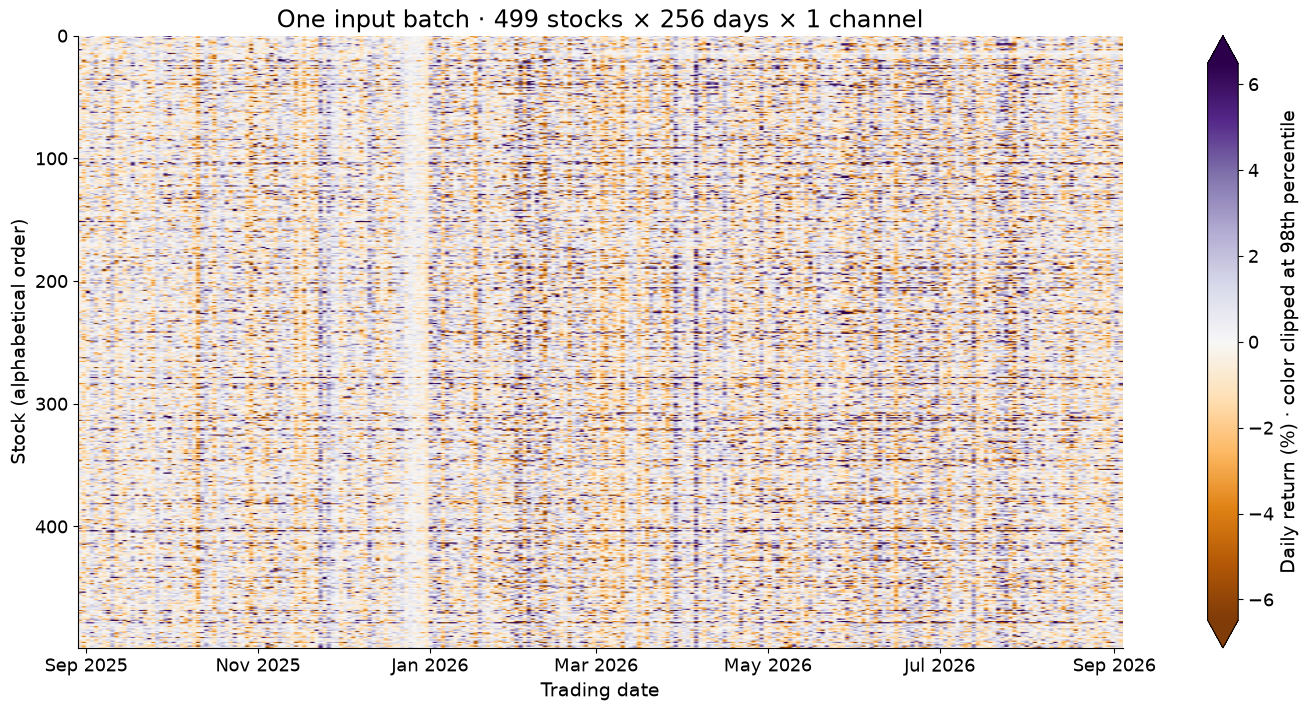

In [29]:
viz.batch_plot(series, dates, FIGURES / "01_stock_batch.png")

## 3 Amortized deployment

One call, internally minibatched. Timing below measures posterior inference.

In [30]:
posterior, inference_seconds = screener.infer_parameters(
    approximator, series, 
    num_samples=512, 
    batch_size=64,
    seed=42
)
print(f"Posterior: {posterior.shape} = (stocks, draws, parameters)")
print(f"{inference_seconds:.2f}s total; {1000 * inference_seconds / len(series):.1f} ms/stock")

Summarizing:   0%|          | 0/8 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/8 [00:00<?, ?batch/s]

Posterior: (499, 512, 4) = (stocks, draws, parameters)
0.55s total; 1.1 ms/stock


## 4 Rank by gain probability per unit of risk

- **Gain probability:** the chance that the next 20-day return covers the 0.20% trading cost.
- **Expected shortfall (ES):** the average gross loss in the worst 5% of simulated 20-day outcomes.
- **Score:** `gain probability (%) / ES (%)`. For example, `70 / 10 = 7`. Higher values combine a greater chance of gain with less downside.

In [7]:
risk_start = perf_counter()
ranking, coverage_checks = screener.screen_stocks(
    posterior, 
    series, 
    metadata, 
    rule=RULE,
    n_parameter_draws=64, 
    n_replications=512, 
    n_ppc=512, 
    seed=43,
)

risk_seconds = perf_counter() - risk_start
ranking.to_csv(FIGURES / "stock_screen.csv", index=False)
coverage_checks.to_csv(FIGURES / "coverage_checks.csv", index=False)

pd.DataFrame({
    "stage": ["Posterior inference", "Risk simulation + predictive checks"],
    "seconds": [inference_seconds, risk_seconds],
    "stocks": [len(series), len(series)],
}).to_csv(FIGURES / "deployment_timing.csv", index=False)
print(f"Ranked {len(ranking)} stocks in {risk_seconds:.1f}s.")

Risk + PPC: 25/499 stocks (7.7s)


Risk + PPC: 50/499 stocks (15.3s)


Risk + PPC: 75/499 stocks (23.0s)


Risk + PPC: 100/499 stocks (30.5s)


Risk + PPC: 125/499 stocks (38.0s)


...

Risk + PPC: 425/499 stocks (130.9s)


Risk + PPC: 450/499 stocks (138.7s)


Risk + PPC: 475/499 stocks (146.5s)


Risk + PPC: 499/499 stocks (154.0s)


Ranked 499 stocks in 154.1s.


### Gain probability and downside

- Left: gain probability against 20-day expected shortfall.
- Right: a forest plot of the top 12. Each dot is the gain/ES score; the line shows its 90% posterior interval.

The colors warn about possible model mismatch. We compare each stock's mean, volatility, return tails and maximum drawdown with 99% prior and posterior predictive ranges. We also flag scale estimates concentrated at the prior limits. Purple means these checks passed; grey means at least one warning. These are rough diagnostics, and every stock keeps its rank.

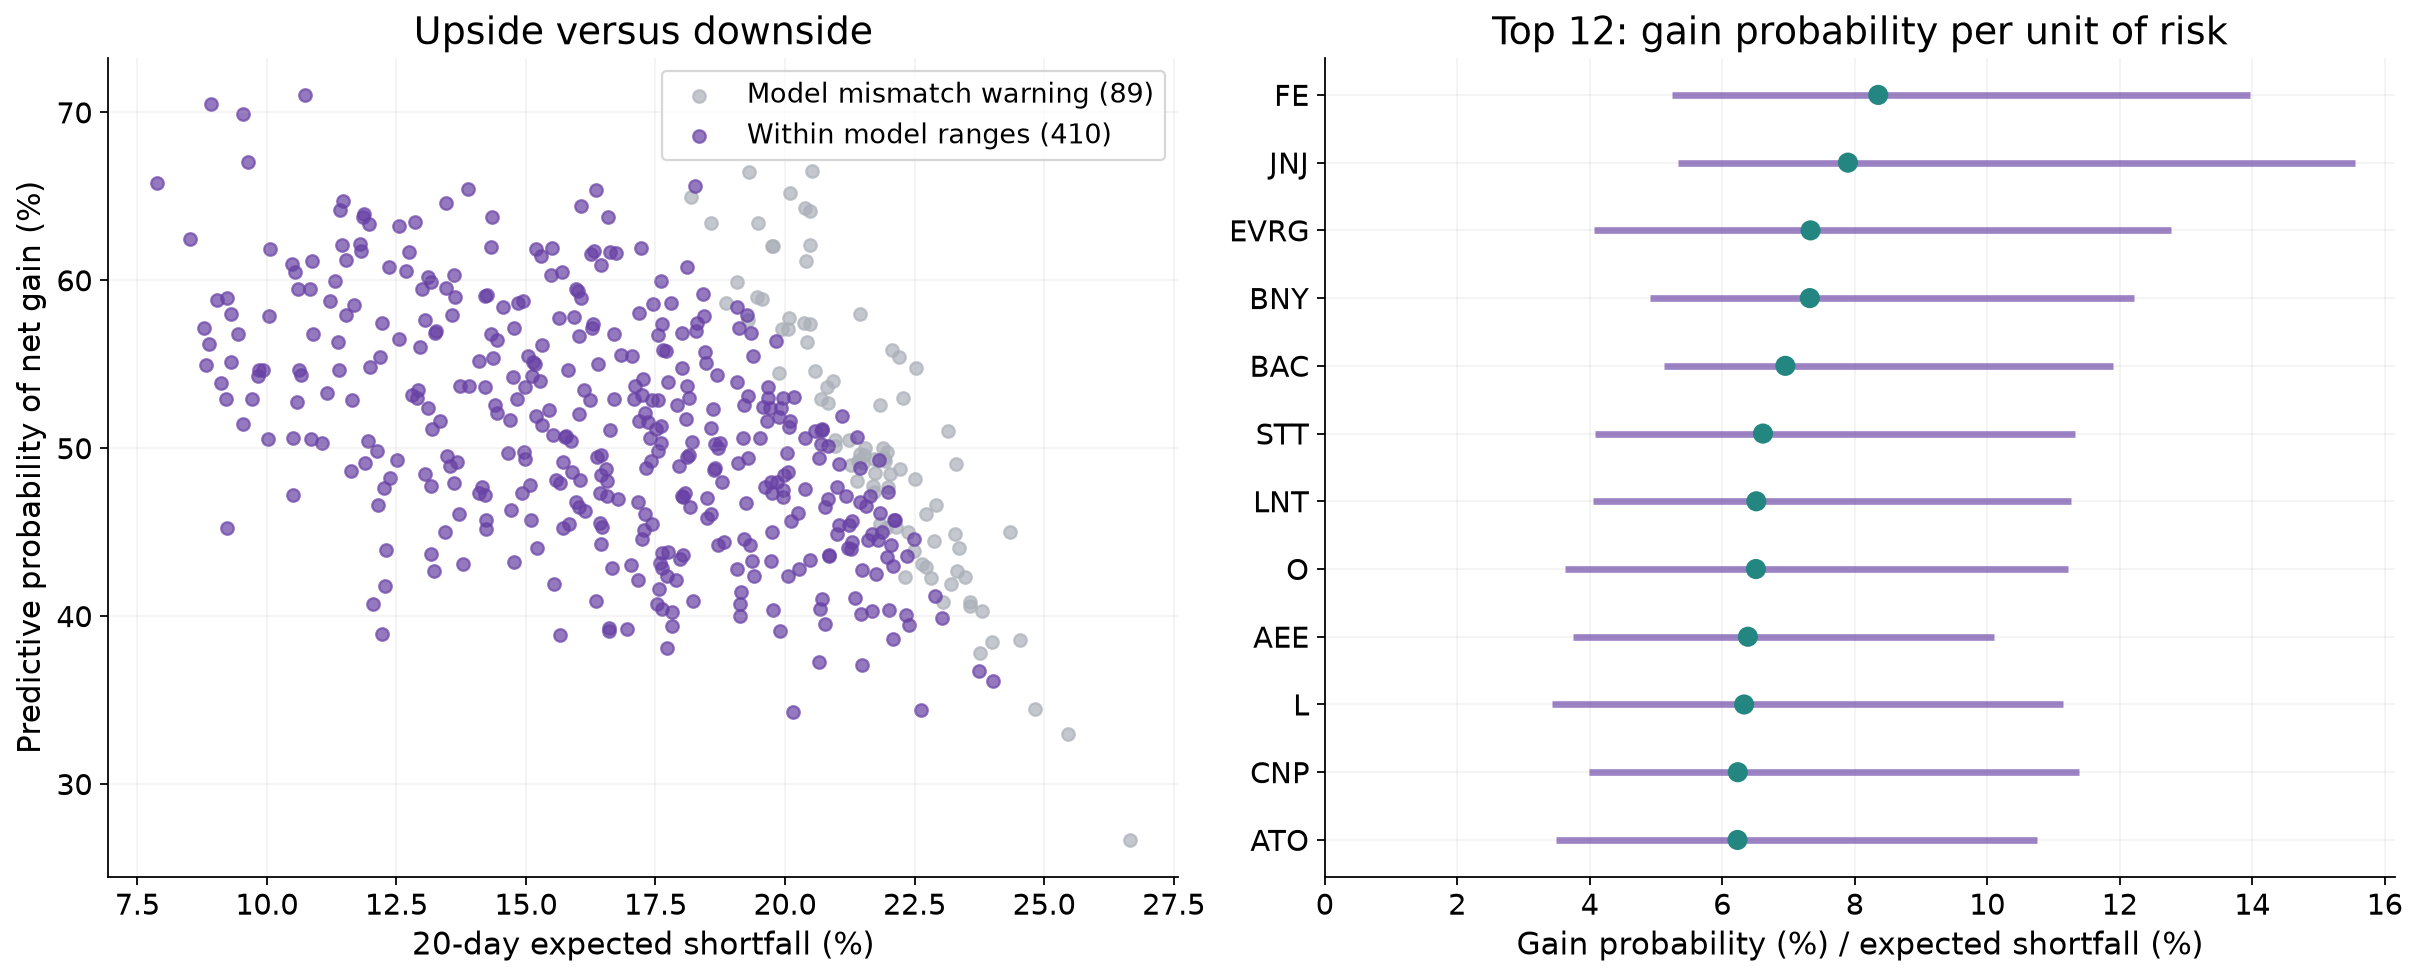

In [8]:
viz.opportunity_plot(ranking, FIGURES / "02_opportunities.png")

### Top five stocks

The table is sorted by gain/ES. Gain probability includes trading costs. `coverage_ok` is true when none of the model-mismatch checks raised a warning.

In [9]:
columns = [
    "rank", "ticker", "sector", "gain_to_es", "predictive_gain_probability",
    "predictive_es95_pct", "es95_posterior_q05_pct", "es95_posterior_q95_pct",
    "coverage_ok",
]

display(ranking[columns].head(5).style.format({"predictive_gain_probability": "{:.1%}"}, precision=2))

,rank,ticker,sector,gain_to_es,predictive_gain_probability,predictive_es95_pct,es95_posterior_q05_pct,es95_posterior_q95_pct,coverage_ok
0,1,FE,Utilities,8.36,65.8%,7.87,5.38,9.66,True
1,2,JNJ,Health Care,7.90,70.5%,8.93,5.48,11.07,True
2,3,EVRG,Utilities,7.33,62.5%,8.51,5.56,10.80,True
3,4,BNY,Financials,7.32,69.9%,9.55,6.58,11.87,True
4,5,BAC,Financials,6.95,67.0%,9.64,6.65,11.55,True


### Parameter estimates

For the top 12 stocks, dots mark posterior medians and lines cover the central 90% of draws. Drift and scale are shown in percent.

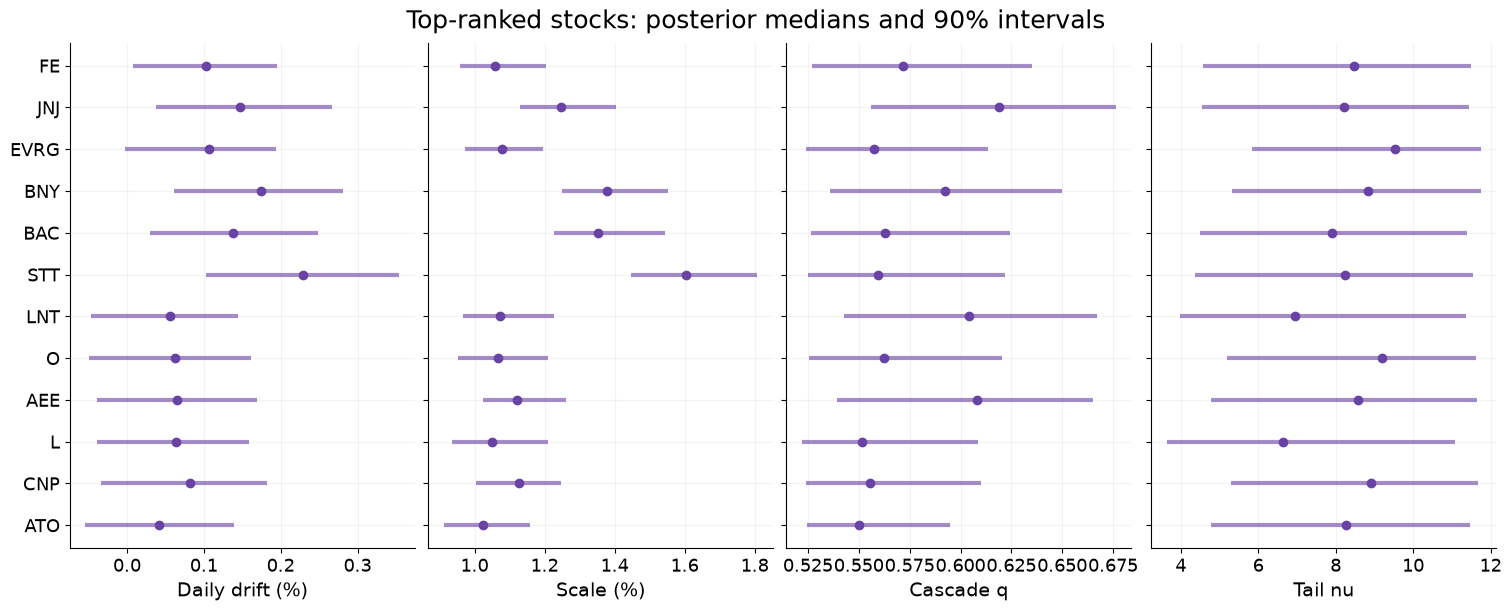

In [10]:
viz.parameter_plot(ranking, FIGURES / "03_parameter_posteriors.png")

## 5 Check the highest-ranked stock

Each posterior draw generates one 256-day return path.

- **Wealth:** observed growth in black dashes, the predictive median in purple, and 68% and 92% predictive intervals.
- **Daily returns:** observed and simulated histograms, with the predictive median marked.
- **Maximum drawdown:** one value per simulated path. The black dashed line marks the observed loss; purple marks the predictive median.

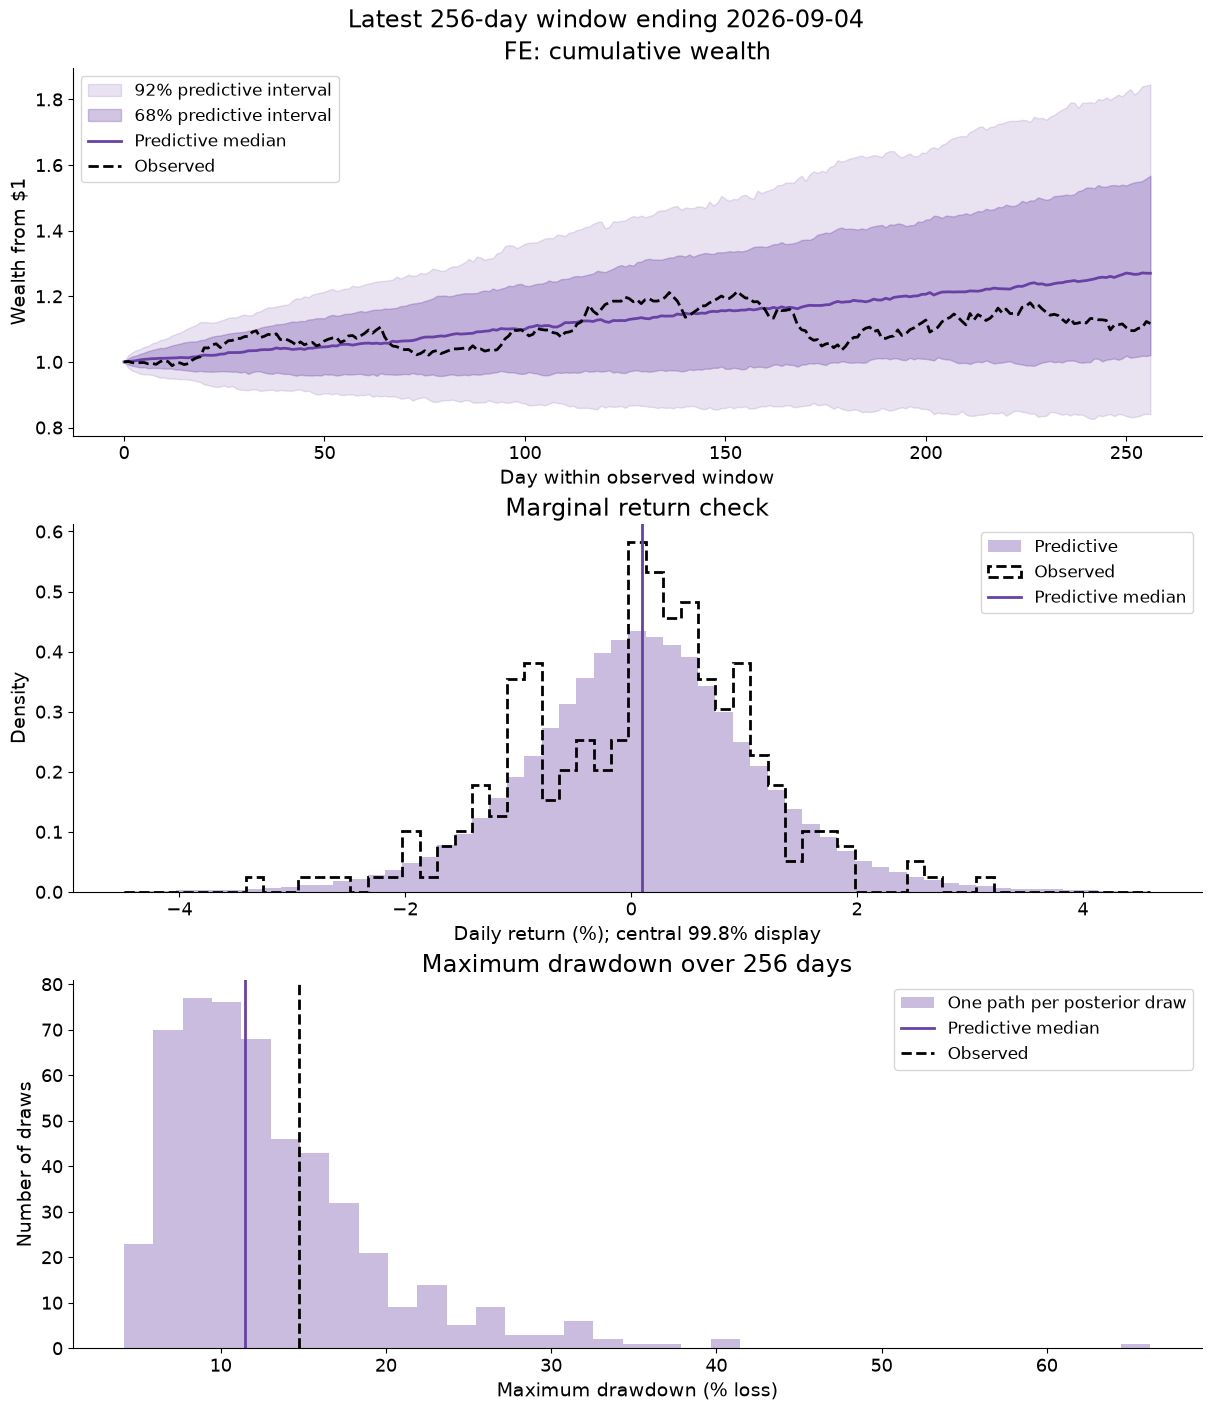

In [11]:
viz.fit_plot(posterior, series, metadata, ranking, dates, FIGURES / "04_leading_stock_fit.png")